In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

Work Root Filepath

In [2]:
print(os.getcwd()) 

d:\01_project\2602-GNN\notebooks


In [3]:
PROJECT_ROOT = r'd:\01_project\2602-GNN'  # 使用原始字符串避免转义问题
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'elliptic_bitcoin_dataset')   # data所在目录

# Data Loading

In [4]:
CLASSES_CSV = os.path.join(DATA_DIR, 'elliptic_txs_classes.csv')
EDGES_CSV = os.path.join(DATA_DIR, 'elliptic_txs_edgelist.csv')
FEATURES_CSV = os.path.join(DATA_DIR, 'elliptic_txs_features.csv')

feature的文件极大，统一了解文件结构、列名、数据基本概况，决定分析思路的前置处理

In [51]:
df_classes = pd.read_csv(CLASSES_CSV,nrows=5)
df_edges = pd.read_csv(EDGES_CSV,nrows=5)
df_features = pd.read_csv(FEATURES_CSV,nrows=5)

print('classes_csv: ',df_classes)
print('edges_csv: ',df_edges)
print('features_csv: ',df_features)

classes_csv:          txId    class
0  230425980  unknown
1    5530458  unknown
2  232022460  unknown
3  232438397        2
4  230460314  unknown
edges_csv:         txId1      txId2
0  230425980    5530458
1  232022460  232438397
2  230460314  230459870
3  230333930  230595899
4  232013274  232029206
features_csv:     230425980  1  -0.1714692896288031  -0.18466755143291433  \
0    5530458  1            -0.171484             -0.184668   
1  232022460  1            -0.172107             -0.184668   
2  232438397  1             0.163054              1.963790   
3  230460314  1             1.011523             -0.081127   
4  230459870  1             0.961040             -0.081127   

   -1.2013688016765636  -0.12196959975910057  -0.04387454791734898  \
0            -1.201369             -0.121970             -0.043875   
1            -1.201369             -0.121970             -0.043875   
2            -0.646376             12.409294             -0.063725   
3            -1.201369        

txId可能为唯一交易编号-作为索引？；feature无列名，第一列txId，但166特征无名

## 1 检查完整数据基本结构情况

In [5]:
df_classes = pd.read_csv(CLASSES_CSV)
df_edges = pd.read_csv(EDGES_CSV)
df_features = pd.read_csv(FEATURES_CSV, header=None)

1.1 数据形状与基本信息

In [53]:
print('Shape of classes', df_classes.shape)
print('Shape of edges', df_edges.shape)
print('Shape of features', df_features.shape)

Shape of classes (203769, 2)
Shape of edges (234355, 2)
Shape of features (203769, 167)


In [54]:
print('dtpye of classes', df_classes.dtypes)
print('dtpye of edges', df_edges.dtypes)
print('dtpye of features', df_features.dtypes)

dtpye of classes txId     int64
class      str
dtype: object
dtpye of edges txId1    int64
txId2    int64
dtype: object
dtpye of features 0        int64
1        int64
2      float64
3      float64
4      float64
        ...   
162    float64
163    float64
164    float64
165    float64
166    float64
Length: 167, dtype: object


1.2 关键字段

In [6]:
df_classes['class'].unique()

<StringArray>
['unknown', '2', '1']
Length: 3, dtype: str

把类别统一为:1-ilicit,2-licit,3-unknow——int!；特征csv修改为前94-local,后72-aggregate

In [7]:
df_classes.loc[df_classes['class'] == 'unknown', 'class'] = '3'

In [8]:
df_classes['class'] = df_classes['class'].astype(int)

In [9]:
# 保持str键
colNames1 = {'0': 'txId', '1': "time_step"}
colNames2 = {str(ii+2): "Local_feature_" + str(ii+1) for ii in range(93)}
colNames3 = {str(ii+95): "Aggregate_feature_" + str(ii+1) for ii in range(72)}
# 合并字典,**展开
colNames = dict(colNames1, **colNames2, **colNames3)
# 字典键转换为int
colNames_int = {int(k): v for k, v in colNames.items()}
# 重命名
df_features = df_features.rename(columns=colNames_int)

print(df_features.columns[:10])  

Index(['txId', 'time_step', 'Local_feature_1', 'Local_feature_2',
       'Local_feature_3', 'Local_feature_4', 'Local_feature_5',
       'Local_feature_6', 'Local_feature_7', 'Local_feature_8'],
      dtype='str')


# EDA

## 1 每类的数量分布

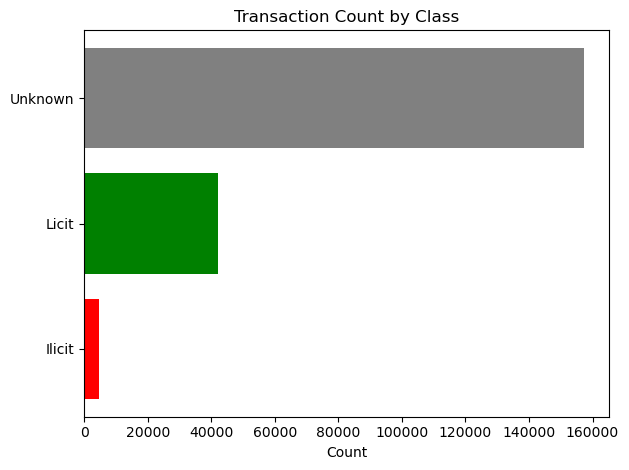

In [10]:
group_class = df_classes.groupby('class').count()
# groupby默认排序123，正好对应Ilicit, Licit, Unknown标签
plt.barh(['Ilicit', 'Licit','Unknown'], group_class['txId'].values, color=['r', 'g','grey'] )
plt.xlabel('Count')
plt.title('Transaction Count by Class')
plt.tight_layout()

## 2 时间步交易量趋势

Text(0.5, 1.0, 'Number of Transactions by Time Step')

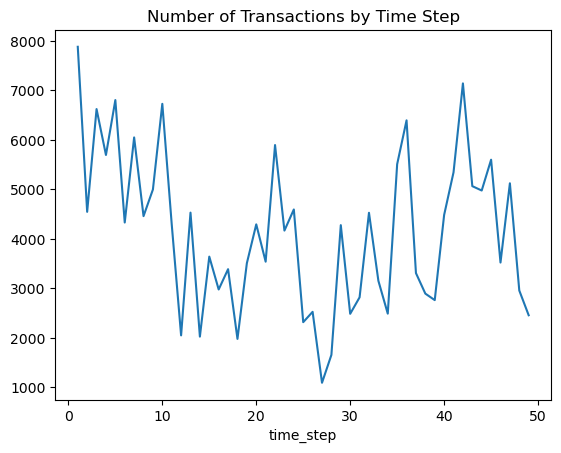

In [11]:
group_feature = df_features.groupby('time_step').count()
group_feature['txId'].plot()
plt.title('Number of Transactions by Time Step')

## 3 合并，分层统计类别在不同时间步

In [12]:
df_class_feature = pd.merge(df_classes, df_features )
df_class_feature.head()

,txId,class,time_step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,...,Aggregate_feature_63,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72
0,230425980,3,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,3,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,3,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,2,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,3,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [13]:
group_class_feature = df_class_feature.value_counts(['time_step', 'class']).reset_index(name='count')
group_class_feature.head()

,time_step,class,count
0,10,3,5755
1,1,3,5733
2,3,3,5342
3,42,3,4986
4,5,3,4921


<Axes: xlabel='time_step', ylabel='count'>

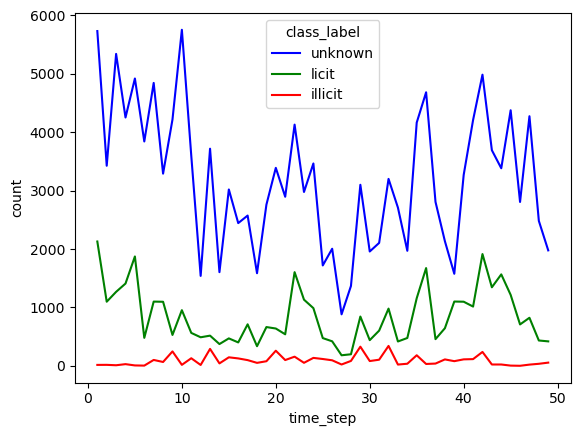

In [14]:
# 添加标签的映射
label_mapping = {
    1: 'illicit',
    2: 'licit', 
    3: 'unknown'
}
group_class_feature['class_label'] = group_class_feature['class'].map(label_mapping)
# 注意palette颜色映射标签
sns.lineplot(x='time_step', y='count', hue='class_label', data = group_class_feature, palette={'illicit': 'r', 'licit': 'g', 'unknown': 'b'})

折线图有些区分不清楚样本量少的欺诈类别的时序变化，再使用堆叠柱状图

In [17]:
group_class_feature.head()

,time_step,class,count,class_label
0,10,3,5755,unknown
1,1,3,5733,unknown
2,3,3,5342,unknown
3,42,3,4986,unknown
4,5,3,4921,unknown


In [22]:
# 检查每个时间步是否都有三个类别的数据
time_steps = sorted(group_class_feature['time_step'].unique())
print(f"总时间步数: {len(time_steps)}")
print(f"时间步范围: {min(time_steps)} 到 {max(time_steps)}")

总时间步数: 49
时间步范围: 1 到 49


In [25]:
group_class_feature['class'].unique()

array([3, 2, 1])

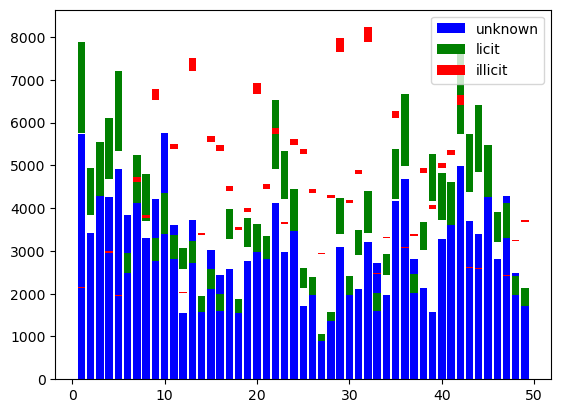

In [ ]:
class1 = group_class_feature[group_class_feature['class'] == 1] # illicit
class2 = group_class_feature[group_class_feature['class'] == 2] # licit
class3 = group_class_feature[group_class_feature['class'] == 3 ] # unknown
# plt.bar绘制直接使用class*没有对齐x轴，索引不一致，需要统一ts作为索引，
# 按顺序绘制，从底向上堆叠，bottom参数设置为前面类别的count值之和
'''p3 = plt.bar(class3['time_step'], class3['count'], color = 'b',label='unknown')
p2 = plt.bar(class2['time_step'], class2['count'], color='g', bottom=class3['count'],label='licit')   # 柱子从class3的count值开始堆叠
p1 = plt.bar(class1['time_step'], class1['count'], color='r', bottom=np.array(class3['count'])+np.array(class2['count']),label='illicit')   # 柱子从class3和class2的count值之和开始堆叠
plt.legend()'''

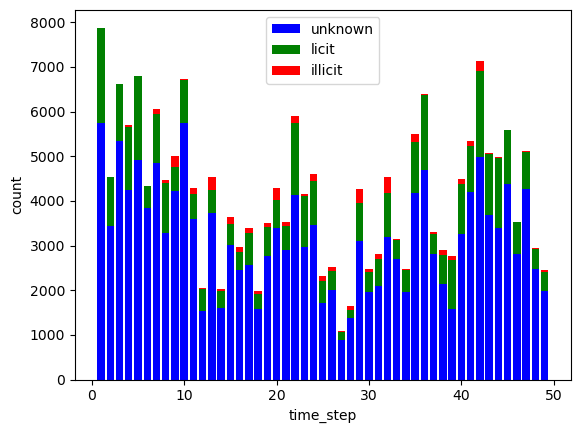

In [ ]:
'''正确堆叠'''
# 所有时间步，作为唯一x轴排序索引
ts = np.sort(group_class_feature['time_step'].unique())

# 重新索引并补零（尽管每ts都包含c）
c1 = class1.set_index('time_step').reindex(ts)['count'].fillna(0).values
c2 = class2.set_index('time_step').reindex(ts)['count'].fillna(0).values
c3 = class3.set_index('time_step').reindex(ts)['count'].fillna(0).values


plt.bar(ts, c3, color='b', label='unknown')
plt.bar(ts, c2, bottom=c3, color='g', label='licit')
plt.bar(ts, c1, bottom=c3 + c2, color='r', label='illicit')
plt.xlabel('time_step'); plt.ylabel('count')
plt.legend()

In [29]:
# 确认类别不平衡程度
label_counts = df_classes['class'].value_counts()
print(f"Illicit: {label_counts.get(1, 0)} ({label_counts.get(1, 0)/len(df_classes)*100:.2f}%)")
print(f"Licit: {label_counts.get(2, 0)} ({label_counts.get(2, 0)/len(df_classes)*100:.2f}%)")
print(f"Unknown: {label_counts.get(3, 0)} ({label_counts.get(3, 0)/len(df_classes)*100:.2f}%)")

Illicit: 4545 (2.23%)
Licit: 42019 (20.62%)
Unknown: 157205 (77.15%)


plt.bar()堆叠的关键原则
1.
x坐标必须完全一致：所有堆叠层必须使用相同的x坐标序列
2.
数组长度必须匹配：x、height、bottom三个数组的长度必须相同
3.
缺失值必须显式处理：对于某些x位置没有数据的类别，高度必须设为0
4.
bottom计算必须精确：每一层的bottom必须是前面所有层的高度累加

标签的时空分布；极端的类别不平衡；欺诈活动的时间聚集性：不要在全图计算指标。应聚焦于有标签的时间段（1-34步），并特别关注 illicit数量出现小高峰的时间窗口。

假设1（连接性）：“欺诈交易作为洗钱的中间环节，其入度（接收交易）和出度（发出交易）是否与合法交易不同？”
待计算的图指标：入度、出度。
假设2（聚集性）：“欺诈交易是否更倾向于彼此连接，形成紧密的小团体（犯罪团伙）？”
待计算的图指标：聚类系数。
假设3（结构性角色）：“欺诈交易是否更多扮演资金枢纽或桥梁的角色？”
待计算的图指标：介数中心性、接近中心性。